<a href="https://colab.research.google.com/github/sergfer26/transformer-studio/blob/main/notebooks/vision_transformer_on_CIFAR_pytoch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Vision Transformers from scratch

## 0. Vision Transformer fundamentals

### 0.1 Terminology for transfomers

| NLP Transformer | Vision Transformer (ViT) | Explanation |
|-----------------|--------------------------|-------------|
| Tokens | Patches | Words/subwords in text → image split into small fixed-size patches |
| Token IDs | Patch Indices | Each patch can be indexed like tokens |
| Token Embedding | Patch Embedding | Converts token/patch index into dense vectors via learned projection |
| Positional Embedding | Positional Embedding | Adds location information for sequence order/spatial structure |
| [CLS] Token | [CLS] Token | Special token to summarize sequence/image → used for classification |
| Encoder Input Sequence | Embedded Patch Sequence | Input to Transformer: tokens + positional encoding OR patches + positional info |


## 1. Import required libraries

In [1]:
import tqdm
import torch
import random
import torchvision

import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from torchvision import datasets, transforms


In [2]:
torch.__version__

'2.12.1'

In [3]:

torchvision.__version__

'0.27.1'

## 2. Setup Device-Agnostic Code

In [4]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    print("No GPU available, using the CPU instead.")


device = torch.device(device)
device

device(type='mps')

In [5]:
!nvidia-smi

zsh:1: command not found: nvidia-smi


In [6]:
print(f"Usinf Device: {device}")

Usinf Device: mps


## 3. Set the seed

In [7]:
torch.manual_seed(42)
if device.type == "cuda":
    torch.cuda.manual_seed(42)
elif device.type == "mps":
    torch.mps.manual_seed(42)
random.seed(42)

## 4. Setting the hyperparameters

In [8]:
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 3e-4
PATCH_SIZE = 4
NUM_CLASSES = 10
IMAGE_SIZE = 32
CHANNELS = 3
EMBED_SIM = 256
NUM_HEADS = 8
DEPTH = 6
MLP_DIM = 512
DROPOUT_RATE = 0.1
DATA_AUGMENTATION = True

## 5. Define Image Transformation

In [9]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
    # 1. Helps the model to converge faster
    # 2. Helps to make the numerical computations stable
])

if DATA_AUGMENTATION:
    transform = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize((0.5), (0.5))
    ])




## 6. Getting a dataset

In [10]:
train_set = datasets.CIFAR10(
                              root='data',
                              train=True,
                              download=True,
                              transform=transform
                              )
# trainloader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True, num_workers=2)

In [11]:
test_set = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)


## 7. Converting our datasets into dataloader

We do this for the following reasons:
1. **Computation efficiency**: The computer hardware may not be able to store in memory at 50_000 images in one hit. So we break it into baches of size BATCH_SIZE.
2. **Iterative training**: It gives the ANN more chances to update its gradient per epoch.

In [12]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
print(f"Number of training samples: {len(train_loader)}")
print(f"Number of testing samples: {len(test_loader)}")

Number of training samples: 391
Number of testing samples: 79


## 8. Building Vision Transformer Model

In [14]:
class PatchEmbedding(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.patch_size = patch_size
        self.num_patches = (image_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches + 1, embed_dim))

    def forward(self, x):
        # batch_size = x.size(0)
        batch_size, channels, height, width = x.shape
        x = self.proj(x)  # (batch_size, embed_dim, height / patch_size, weidth / patch_size)
        x = x.flatten(2).transpose(1, 2)  # (batch_size, num_patches, embed_dim)
        cls_token = self.cls_token.expand(batch_size, -1, -1)  #
        x = torch.cat((cls_token, x), dim=1)  # (batch_size, num_patches + 1, embed_dim)
        x = x + self.pos_embed  # (batch_size, num_patches + 1, embed_dim)
        return x

In [15]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, dropout_rate):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.fc2 = nn.Linear(hidden_features, in_features)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.gelu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)
        return x

In [16]:
class TransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout_rate):
        super(TransformerEncoderLayer, self).__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = MLP(embed_dim, mlp_dim, dropout_rate)

    def forward(self, x):
        # Multi-head Self-Attention
        x_norm = self.norm1(x)
        attn_output, _ = self.attn(x_norm, x_norm, x_norm)
        x = x + attn_output  # Residual connection

        # MLP
        x_norm = self.norm2(x)
        mlp_output = self.mlp(x_norm)
        x = x + mlp_output  # Residual connection

        return x

In [17]:
class VisionTransformer(nn.Module):
    def __init__(self, image_size, patch_size, in_channels, num_classes, embed_dim, depth, num_heads, mlp_dim, dropout_rate):
        super(VisionTransformer, self).__init__()
        self.patch_embedding = PatchEmbedding(image_size, patch_size, in_channels, embed_dim)
        self.encoder = nn.Sequential(*[
            TransformerEncoderLayer(embed_dim, num_heads, mlp_dim, dropout_rate) for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embedding(x)
        x = self.encoder(x)
        x = self.norm(x)
        cls_token_final = x[:, 0]  # Extract the class token
        logits = self.head(cls_token_final)
        return logits

In [18]:
model = VisionTransformer(
    image_size=IMAGE_SIZE,
    patch_size=PATCH_SIZE,
    in_channels=CHANNELS,
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_SIM,
    depth=DEPTH,
    num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM,
    dropout_rate=DROPOUT_RATE
).to(device)



In [19]:
model

VisionTransformer(
  (patch_embedding): PatchEmbedding(
    (proj): Conv2d(3, 256, kernel_size=(4, 4), stride=(4, 4))
  )
  (encoder): Sequential(
    (0): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (mlp): MLP(
        (fc1): Linear(in_features=256, out_features=512, bias=True)
        (fc2): Linear(in_features=512, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
    )
    (1): TransformerEncoderLayer(
      (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True, bias=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
      )
      (norm2): LayerNorm((256,), eps=1e-05, elem

## 9. Defining a Loss function and Optimizer

In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [21]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0003
    maximize: False
    weight_decay: 0
)

In [22]:
def fit(
    model: torch.nn.Module, 
    dataloader: torch.utils.data.DataLoader, 
    optimizer: torch.optim.Optimizer, 
    criterion: torch.nn.Module, 
    pbar: tqdm.tqdm
    ) -> tuple[float, float]:
  running_loss = 0.0
  correct = 0
  total = 0
  for i, (X, Y) in enumerate(dataloader, 0):
    # 0. Move the data to the device (GPU or CPU)
    X, Y = X.to(device), Y.to(device)
    # 1. Reset the gradients
    optimizer.zero_grad()
    # 2. Forward pass (model output raw logits)
    pred = model(X)
    # 3. Compute the loss (per batch)
    loss = criterion(pred, Y)
    # 4. Perform backpropagation
    loss.backward()
    # 5. Update the model parameters (gradient descent step) 
    optimizer.step()

    running_loss += loss.item()
    avg_loss = running_loss/(i + 1)
    probs = F.softmax(pred, 1)
    label = torch.argmax(probs, dim=1)
    correct += torch.sum(label == Y).item()
    total += Y.shape[0]
    acc = correct/total
        
    pbar.set_postfix(avg_loss='{:.4f}'.format(avg_loss), acc='{:.4f}'.format(acc))
    pbar.update(Y.shape[0])
  return avg_loss, acc

In [23]:
def evaluate(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader) -> tuple[float, float]:
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.inference_mode():
        for i, (X, Y) in enumerate(dataloader, 0):
            X, Y = X.to(device), Y.to(device)
            pred = model(X)

            probs = F.softmax(pred, 1)
            label = torch.argmax(probs, dim=1)
            correct += torch.sum(label == Y).item()
    return correct / len(dataloader.dataset)

### Training

In [24]:
train_accuracies, test_accuracies = [], []

for epoch in range(EPOCHS):
    train_loss, train_acc = fit(model, train_loader, optimizer, criterion, tqdm.tqdm(total=len(train_loader.dataset), desc=f"Epoch {epoch + 1}/{EPOCHS}"))
    test_acc = evaluate(model, test_loader)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    tqdm.tqdm.write(f"Epoch {epoch + 1}/{EPOCHS} - Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/10: 100%|██████████| 50000/50000 [00:43<00:00, 1158.50it/s, acc=0.2999, avg_loss=1.9065]


Epoch 1/10 - Train Loss: 1.9065, Train Acc: 0.2999, Test Acc: 0.3814


Epoch 2/10: 100%|██████████| 50000/50000 [00:37<00:00, 1336.70it/s, acc=0.4182, avg_loss=1.6033]


Epoch 2/10 - Train Loss: 1.6033, Train Acc: 0.4182, Test Acc: 0.4503


Epoch 3/10: 100%|██████████| 50000/50000 [00:39<00:00, 1268.30it/s, acc=0.4647, avg_loss=1.4854]


...

Epoch 8/10 - Train Loss: 1.1863, Train Acc: 0.5749, Test Acc: 0.5749


Epoch 9/10: 100%|██████████| 50000/50000 [00:38<00:00, 1282.56it/s, acc=0.5908, avg_loss=1.1460]


Epoch 9/10 - Train Loss: 1.1460, Train Acc: 0.5908, Test Acc: 0.5851


Epoch 10/10: 100%|██████████| 50000/50000 [00:38<00:00, 1284.54it/s, acc=0.6058, avg_loss=1.1043]


Epoch 10/10 - Train Loss: 1.1043, Train Acc: 0.6058, Test Acc: 0.6081


In [25]:
test_accuracies

[0.3814,
 0.4503,
 0.4819,
 0.5004,
 0.5351,
 0.5421,
 0.5549,
 0.5749,
 0.5851,
 0.6081]

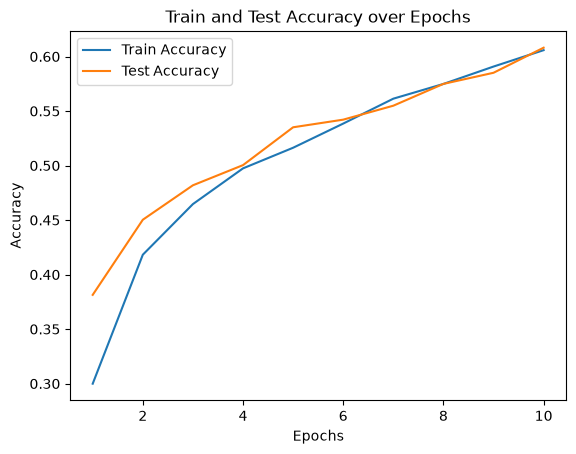

In [26]:
plt.plot(range(1, EPOCHS + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, EPOCHS + 1), test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and Test Accuracy over Epochs')
plt.legend()
plt.show()

In [27]:
def predict_and_plot(model: nn.Module, dataset, classes, grid_size=3):
    model.eval()
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    for i in range(grid_size):
        for j in range(grid_size):
            idx = random.randint(0, len(dataset) - 1)
            img, label = dataset[idx]
            img_input = img.unsqueeze(0).to(device)
            with torch.inference_mode():
                pred = model(img_input)
            pred_label = torch.argmax(pred, dim=1).item()
            if classes[label] == classes[pred_label]:
                color = 'green'
            else:
                color = 'red'
            axes[i, j].imshow(img.permute(1, 2, 0) * 0.5 + 0.5)  # Unnormalize
            axes[i, j].set_title(f"True: {classes[label]}\nPred: {classes[pred_label]}", color=color)
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()

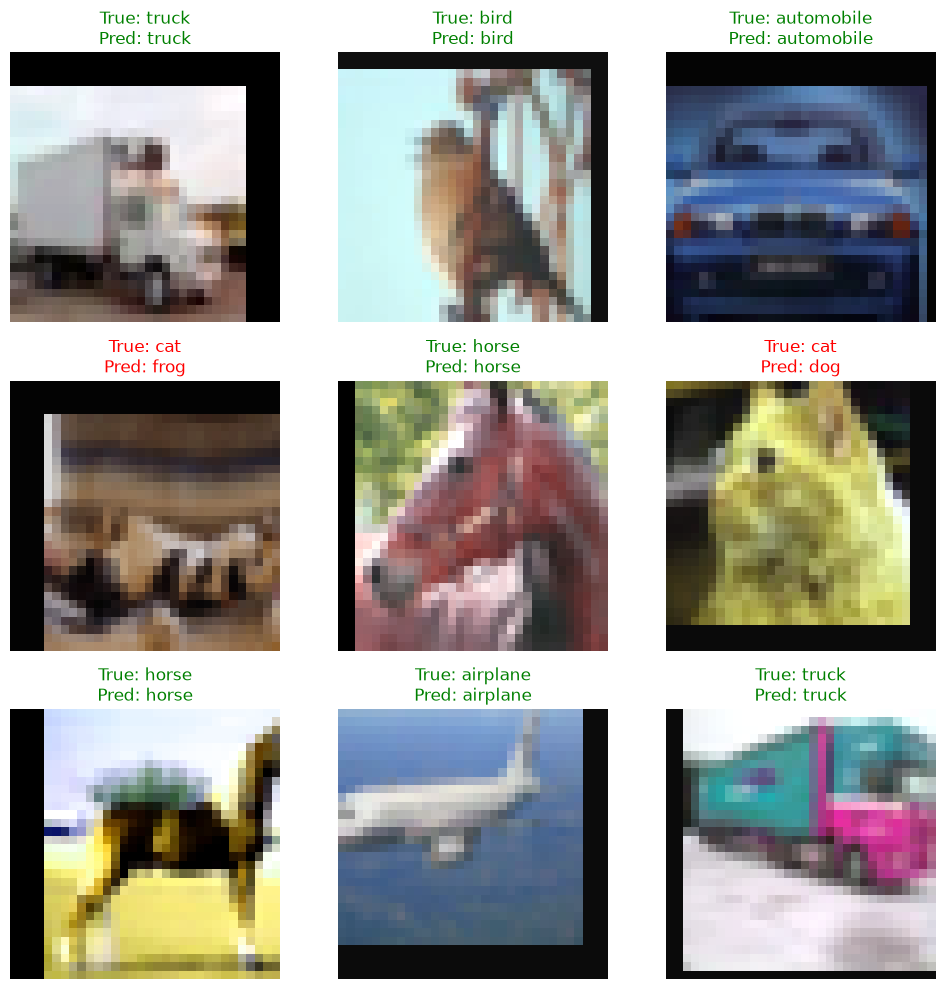

In [28]:
predict_and_plot(model, test_set, train_set.classes, grid_size=3)